In [1]:
# Purpose of this notebook is to learn the concept of Binning
import pandas as pd;
import numpy as np;
from sklearn.preprocessing import KBinsDiscretizer;
from sklearn.model_selection import train_test_split;

In [2]:
df = pd.read_csv("../datasets/train.csv", usecols=['Age', 'Fare', 'Survived'])

In [3]:
df.head(5)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [308]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


## Imputation on the Missing Data

In [309]:
X = df.drop('Survived', axis=1);
y = df[['Survived']];

In [310]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0);

In [311]:
from sklearn.compose import ColumnTransformer;
from sklearn.impute import SimpleImputer;

In [312]:
# Performing Imputation on the Age column for the missing values
transformer = ColumnTransformer([
    ('si_num', SimpleImputer(strategy='median'), ['Age']),
],remainder='passthrough', verbose_feature_names_out=False);

X_train_trans = transformer.fit_transform(X_train);
X_test_trans = transformer.transform(X_test);

columns=transformer.get_feature_names_out()

X_train = pd.DataFrame(X_train_trans, columns = columns, index=X_train.index)
X_test = pd.DataFrame(X_test_trans, columns=columns, index=X_test.index)

In [313]:
# Checking if the missing values are filled by median value or not
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 623 entries, 857 to 684
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     623 non-null    float64
 1   Fare    623 non-null    float64
dtypes: float64(2)
memory usage: 14.6 KB


## Checking Decision Tree A?ccuracy Without Binning

In [314]:
from sklearn.tree import DecisionTreeClassifier;
from sklearn.metrics import accuracy_score;
from sklearn.model_selection import cross_val_score;

In [315]:
# Using Decision Tree Classifier
clf = DecisionTreeClassifier(criterion='entropy', random_state=0)

In [316]:
# Fit on the test data
clf.fit(X_train, y_train);
# Predicted value for X_test
y_test_predicted = clf.predict(X_test);
# Calculating score on the y_test and y_test_predicted to see the correct data
score = accuracy_score(y_test, y_test_predicted);

In [317]:
score

0.6865671641791045

In [318]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv = 10, scoring= 'accuracy'))

np.float64(0.6622097378277153)

## Checking Decision Tree Accuracy With Binning

In [319]:
transformer = ColumnTransformer([
    ('kbin_age', KBinsDiscretizer(n_bins = 10, encode = 'ordinal', strategy='kmeans', random_state = 0), ['Age']),
    ('kbin_fare', KBinsDiscretizer(n_bins = 10, encode = 'ordinal', strategy='kmeans', random_state = 0), ['Fare']),
], verbose_feature_names_out=False, remainder='passthrough', sparse_threshold=0);

X_train_trans = transformer.fit_transform(X_train);
X_test_trans = transformer.transform(X_test);

In [320]:
edges_age = transformer.named_transformers_['kbin_age'].bin_edges_
edges_fare = transformer.named_transformers_['kbin_fare'].bin_edges_

In [321]:
edges_age

array([array([ 0.67      ,  8.87403846, 17.79410727, 24.96750605, 32.49049279,
              40.03490338, 47.16268116, 54.5547619 , 63.03571429, 72.21428571,
              80.        ])                                                   ],
      dtype=object)

In [322]:
edges_fare

array([array([  0.        ,  16.82574954,  29.03045677,  43.70416068,
               65.76706664,  99.6072    , 137.2266317 , 185.37887143,
              238.30379286, 385.7297    , 512.3292    ])             ],
      dtype=object)

In [323]:
pd.DataFrame(X_train_trans)

,0,1
0,6.0,1.0
1,6.0,4.0
2,0.0,3.0
3,6.0,4.0
4,3.0,0.0
...,...,...
618,4.0,4.0
619,2.0,0.0
620,3.0,0.0
621,4.0,1.0


In [324]:
X_train.head(5)

,Age,Fare
857,51.0,26.5500
52,49.0,76.7292
386,1.0,46.9000
124,54.0,77.2875
578,29.0,14.4583


In [325]:
output = pd.DataFrame({
    'age': X_train['Age'],
    'trf_age': X_train_trans[:, 0],
    'fare': X_train['Fare'],
    'trf_fare': X_train_trans[:, 1],
    
})

<Axes: ylabel='Frequency'>

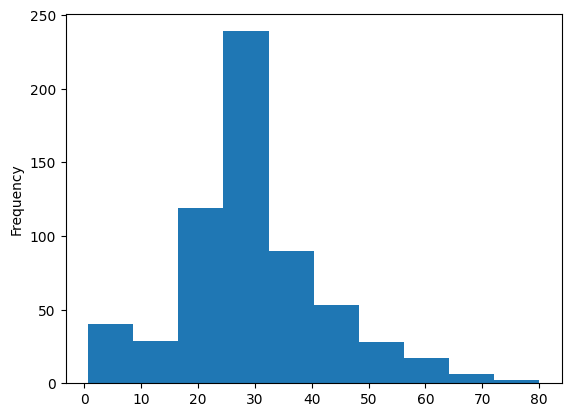

In [326]:
output['age'].plot(kind = 'hist')

<Axes: ylabel='Frequency'>

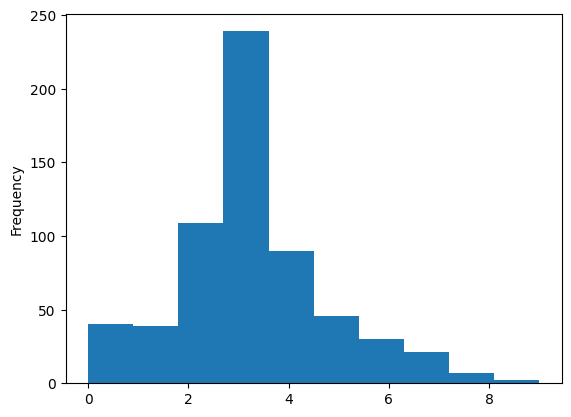

In [327]:
output["trf_age"].plot(kind = 'hist')

In [328]:
# Using Decision Tree Classifier
clf = DecisionTreeClassifier(criterion='entropy', random_state=0)
# Fit on the test data
clf.fit(pd.DataFrame(X_train_trans), y_train);
# Predicted value for X_test
y_test_predicted = clf.predict(pd.DataFrame(X_test_trans));
# Calculating score on the y_test and y_test_predicted to see the correct data
score = accuracy_score(y_test, y_test_predicted);
score

0.7164179104477612

In [329]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv = 10, scoring= 'accuracy'))

np.float64(0.6644694132334583)